In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amineipad/titanic-dataset/train.csv
/kaggle/input/datasets/amineipad/titanic-dataset/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path_train = "/kaggle/input/datasets/amineipad/titanic-dataset/train.csv"
file_path_test = "/kaggle/input/datasets/amineipad/titanic-dataset/test.csv"

train_data = pd.read_csv(file_path_train , index_col = 'PassengerId')
test_data = pd.read_csv (file_path_test , index_col = 'PassengerId')


In [4]:
#Reading data 

train_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [5]:
test_data

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [6]:
import pandas as pd
import re

for df in [train_data, test_data]:

    if 'Name' in df.columns:
        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        
        df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
        df['Title'] = df['Title'].replace('Mlle', 'Miss')
        df['Title'] = df['Title'].replace('Ms', 'Miss')
        df['Title'] = df['Title'].replace('Mme', 'Mrs')
    else:
        print("Warning")
        
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = 0
    df['IsAlone'].loc[df['FamilySize'] == 1] = 1

/tmp/ipykernel_58/3784994055.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['IsAlone'].loc[df['FamilySize'] == 1] = 1
/tmp/ipykernel_58/3784994055.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

Ticket Column has random number and object values that have no information to the model
So we will drop it.
The same like Name that have no information to the model

In [7]:
train_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,1,1
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,4,0


In [8]:
train_data = train_data.drop(['Ticket' , 'Name'] , axis = 1, errors='ignore')
test_data = test_data.drop(['Ticket' , 'Name'] , axis = 1, errors = 'ignore')

In [9]:
test_data

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
PassengerId,,,,,,,,,,,
892,3,male,34.5,0,0,7.8292,NaN,Q,Mr,1,1
893,3,female,47.0,1,0,7.0000,NaN,S,Mrs,2,0
894,2,male,62.0,0,0,9.6875,NaN,Q,Mr,1,1
895,3,male,27.0,0,0,8.6625,NaN,S,Mr,1,1
896,3,female,22.0,1,1,12.2875,NaN,S,Mrs,3,0
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,male,NaN,0,0,8.0500,NaN,S,Mr,1,1
1306,1,female,39.0,0,0,108.9000,C105,C,Rare,1,1
1307,3,male,38.5,0,0,7.2500,NaN,S,Mr,1,1


In [10]:
train_data.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Cabin         687
Embarked        2
Title           0
FamilySize      0
IsAlone         0
dtype: int64

In [11]:
train_data.drop('Cabin' , axis = 1 , inplace= True)
test_data.drop('Cabin' , axis = 1 , inplace= True)


In [12]:
train_data


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
2,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0
3,1,3,female,26.0,0,0,7.9250,S,Miss,1,1
4,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0
5,0,3,male,35.0,0,0,8.0500,S,Mr,1,1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,S,Rare,1,1
888,1,1,female,19.0,0,0,30.0000,S,Miss,1,1
889,0,3,female,NaN,1,2,23.4500,S,Miss,4,0


In [13]:
test_data

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
PassengerId,,,,,,,,,,
892,3,male,34.5,0,0,7.8292,Q,Mr,1,1
893,3,female,47.0,1,0,7.0000,S,Mrs,2,0
894,2,male,62.0,0,0,9.6875,Q,Mr,1,1
895,3,male,27.0,0,0,8.6625,S,Mr,1,1
896,3,female,22.0,1,1,12.2875,S,Mrs,3,0
...,...,...,...,...,...,...,...,...,...,...
1305,3,male,NaN,0,0,8.0500,S,Mr,1,1
1306,1,female,39.0,0,0,108.9000,C,Rare,1,1
1307,3,male,38.5,0,0,7.2500,S,Mr,1,1


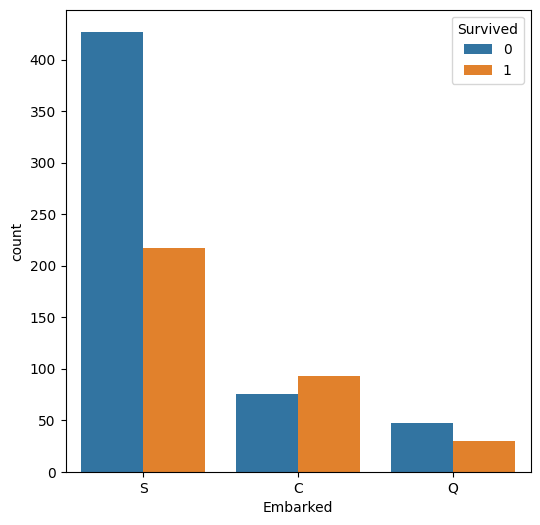

In [14]:
plt.figure(figsize = (6,6))

sns.countplot(x='Embarked', hue='Survived', data=train_data)
plt.show()

* **Observation:** The countplot clearly shows that the survival rate differs significantly based on the port of embarkation (`Embarked`).
* **Key Insights:**
  * Passengers who embarked from *Port C * have a higher survival rate (more survivors than non-survivors).
  * Passengers from *Port S * represent the majority but have a drastically lower survival rate.
  * This will help the model a lot

<Axes: xlabel='Age', ylabel='Count'>

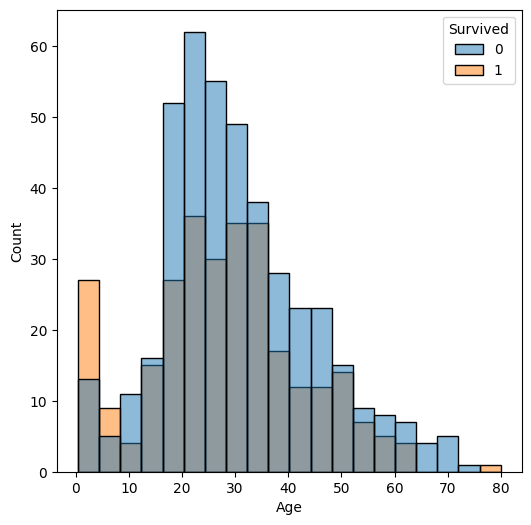

In [15]:
plt.figure(figsize = (6,6))

sns.histplot(x = 'Age' , hue = 'Survived' , data= train_data)

* **Observation:** The KDE/Histplot shows that the survival rate varies significantly based on the passenger's `Age`.
* **Key Insights:**
  * **Children (Age < 10):** Have a much higher chance of survival, creating a visible peak in the survival curve (due to the "women and children first" rule).
  * **Young Adults & Middle-Aged (Age 16 - 50):** Show a much higher mortality rate (the blue curve dominates), as this group includes most of the male passengers and crew who stayed behind.
  * This will help a lot

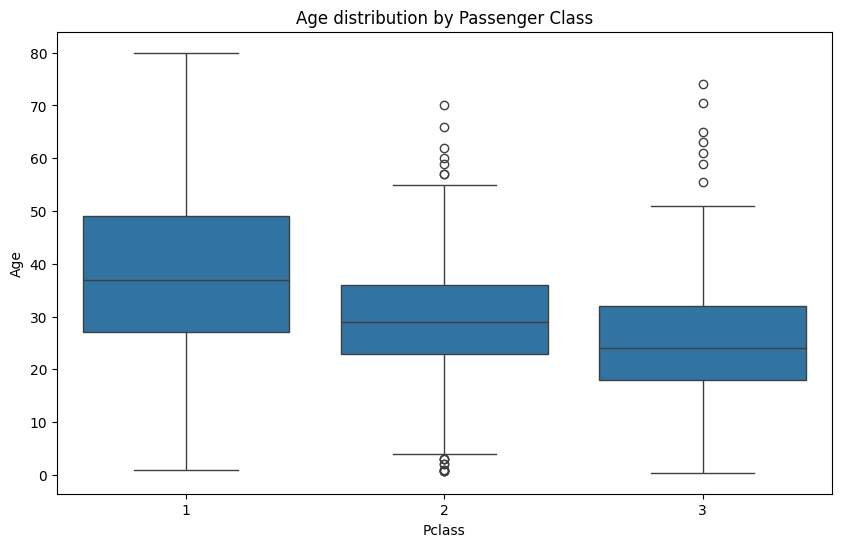

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=train_data)
plt.title('Age distribution by Passenger Class')
plt.show()

In [17]:
# Fill NaN values in 'Age' feature based on 'Pclass'

age_map = train_data.groupby('Pclass')['Age'].median().to_dict()
print(age_map)

train_data['Age'] = train_data['Age'].fillna(train_data['Pclass'].map(age_map))
test_data['Age']  = test_data['Age'].fillna(test_data['Pclass'].map(age_map))

{1: 37.0, 2: 29.0, 3: 24.0}


In [18]:
# Fill NaN values in 'Embarked' feature based on 'Pclass'

embarked = train_data['Embarked'].mode()[0]

train_data['Embarked'] = train_data['Embarked'].fillna(embarked)
test_data['Embarked']  = test_data['Embarked'].fillna(embarked)

In [19]:
#checking null values

train_data.isnull().sum()
print(f"=============")
test_data.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          1
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

In [20]:
train_fare_median = train_data['Fare'].median()

test_data['Fare'] = test_data['Fare'].fillna(train_fare_median)


In [21]:
cols_obj = train_data.select_dtypes(include = "object").columns
print(cols_obj)

Index(['Sex', 'Embarked', 'Title'], dtype='object')


In [22]:
X = train_data.drop('Survived' , axis = 1)
y = train_data['Survived']

X_test = test_data


In [23]:
from sklearn.model_selection import train_test_split

X_train , X_valid , y_train , y_valid = train_test_split(X , y , train_size = 0.9 , random_state = 0)

In [24]:
#Performing one hot encoding

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False)

OH_cols_train = pd.DataFrame(ohe.fit_transform(X_train[cols_obj]),
                            columns = ohe.get_feature_names_out(cols_obj))
OH_cols_valid = pd.DataFrame(ohe.transform(X_valid[cols_obj]),
                              columns = ohe.get_feature_names_out(cols_obj))
OH_cols_test = pd.DataFrame(ohe.transform(X_test[cols_obj]) ,
                            columns = ohe.get_feature_names_out(cols_obj))

OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index
OH_cols_test.index = X_test.index


num_cols_train = X_train.drop(cols_obj , axis = 1)
num_cols_valid = X_valid.drop(cols_obj , axis = 1)
num_cols_test = X_test.drop(cols_obj , axis = 1)


X_train_final = pd.concat([num_cols_train , OH_cols_train] , axis = 1)
X_valid_final = pd.concat([num_cols_valid , OH_cols_valid] , axis = 1)
X_test_final = pd.concat([num_cols_test , OH_cols_test] , axis = 1)


In [25]:
X_train_final

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
PassengerId,,,,,,,,,,,,,,,,,
816,1,37.0,0,0,0.0000,1,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
878,3,19.0,0,0,7.8958,1,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
194,2,3.0,1,1,26.0000,3,0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
524,1,44.0,0,1,57.9792,2,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
635,3,9.0,3,2,27.9000,6,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,1,39.0,1,1,83.1583,3,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
193,3,19.0,1,0,7.8542,2,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
630,3,24.0,0,0,7.7333,1,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


<Axes: >

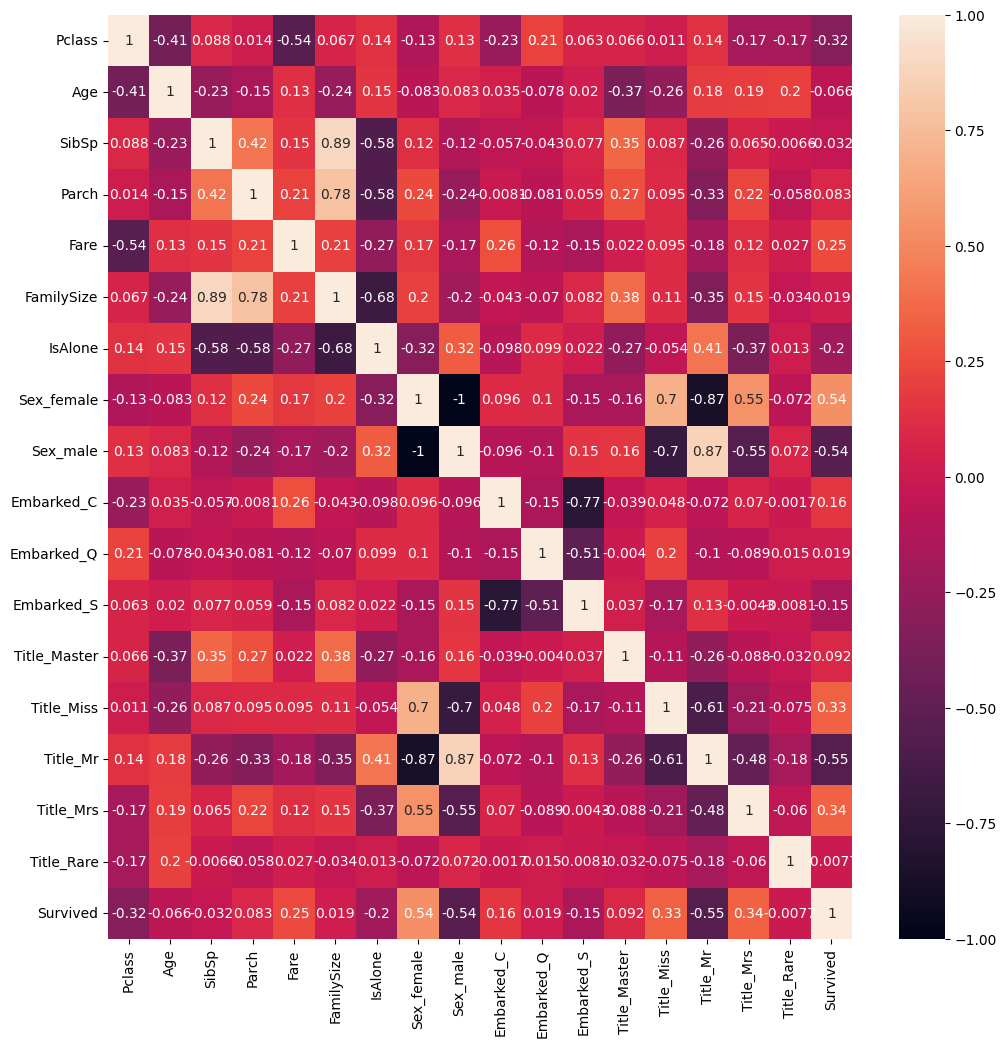

In [26]:
data_heatmap = X_train_final.copy()
data_heatmap['Survived'] = y_train

plt.figure(figsize = (12 , 12))
sns.heatmap(data = data_heatmap.corr() , annot = True)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=10000)

model.fit(X_train_final, y_train)

train_pred = model.predict(X_train_final)
pred = model.predict(X_valid_final)

accuracy_train = accuracy_score(y_train , train_pred)
accuracy_valid = accuracy_score(y_valid, pred)
print(f"train Accuracy: {accuracy_train * 100:.2f}%")
print(f"Validation Accuracy: {accuracy_valid * 100:.2f}%")

train Accuracy: 83.02%
Validation Accuracy: 84.44%


In [28]:
test_pred = model.predict(X_test_final)

#submission = pd.DataFrame({'PassengerId' : X_test_final.index , 'Survived' : test_pred})

#submission.to_csv('submission.csv', index=False)

#print(" submission.csv! 🎉")

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

rf_model = RandomForestClassifier(
    n_estimators=100,    
    max_depth=5,            
    random_state=42
)

rf_model.fit(X_train_final, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train_final))
rf_val_acc = accuracy_score(y_valid, rf_model.predict(X_valid_final))

print("=== 🌲 Random Forest Results ===")
print(f"Train Accuracy: {rf_train_acc * 100:.2f}%")
print(f"Validation Accuracy: {rf_val_acc * 100:.2f}%")

rf_preds = rf_model.predict(X_test_final)
#submission_rf = pd.DataFrame({'PassengerId': test_data.index, 'Survived': rf_preds})
#submission_rf.to_csv('submission_rf.csv', index=False)

=== 🌲 Random Forest Results ===
Train Accuracy: 83.90%
Validation Accuracy: 83.33%


To make models more accuracy  We will perform feature engineering

In [33]:
#Gridsearch
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv_method = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# بناء الـ GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv_method,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1           
)

print("Searching for best parameters ⏳")
grid_search.fit(X_train_final, y_train)


print(f"best dev score: {grid_search.best_score_ * 100:.2f}%")
print(f"best params: {grid_search.best_params_}")

best_rf_model = grid_search.best_estimator_



Searching for best parameters ⏳
Fitting 5 folds for each of 360 candidates, totalling 1800 fits
best dev score: 83.52%
best params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


In [34]:
final_preds = best_rf_model.predict(X_test_final)
submission_grid = pd.DataFrame({'PassengerId': test_data.index, 'Survived': final_preds})
submission_grid.to_csv('submission_grid_rf.csv', index=False)
print("submission_grid_rf.csv 🚀")

submission_grid_rf.csv 🚀
